# Extending diffsed

This notebook is for **developers** who want to add new components to
diffsed: custom priors, PSD models, dust laws, mean SFHs, or filter
sets.

The standardized architecture makes this elegant.  The core insight
from Information Field Theory (En{\ss}lin 2019):

> **One loss function.  Any prior.  Any sampler.**
>
> $H(\xi) = \tfrac{1}{2}\chi^2(d, f(\xi)) + \tfrac{1}{2}\xi^T\xi$

Every parameter lives in **standardized space** $\xi \sim \mathcal{N}(0, I)$.
Priors are absorbed into differentiable transforms $\xi \to \theta$.
The loss never needs to know about priors -- they are baked into the
forward model.

**Prerequisites:** Tutorials 00--02 (basic usage), Tutorial 06
(StandardizedForwardModel internals).

**Reference:** `ARCHITECTURE.md` for the full design philosophy.

## Architecture Overview

The forward model is a layered pipeline:

```
Data (observed photometry / spectrum)
 ^
 |  chi-squared likelihood
 |
Observation layer (filter convolution / spectroscopy)
 ^
SPS layer (SSP weighting by SFH + metallicity)
 ^
Dust layer (Charlot & Fall attenuation)
 ^
SFH layer (mean SFH * exp(GP field))
 ^
PSD layer (sqrt power spectrum -> correlated field)
 ^
Priors (Distribution.unstandardize: xi -> theta)
 ^
Standardized latents: xi ~ N(0, I)
```

`StandardizedForwardModel` sits at the center: it maps
$\xi \sim \mathcal{N}(0, I)$ through the full pipeline to observables.
Every layer is a pure JAX function -- differentiable end to end.

**To extend diffsed, you swap one layer.  Everything else composes.**

In [1]:
import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)
import matplotlib.pyplot as plt
import numpy as np

import sys; sys.path.insert(0, ".")
from _plot_style import setup_style, COLORS, SDSS_WAVE_EFF, safe_corner
setup_style()

from diffsed import (
    Model, ParamSpec, Uniform, Gaussian, LogUniform, LogNormal,
    StudentT, Fixed, Fitter, load_ssp_data, load_filter_set,
)
from diffsed.distributions import Distribution
from diffsed.standardized import StandardizedForwardModel
from diffsed.models.sfh.gp_sfh import compute_sqrt_power_drw
from diffsed.models.sfh.gp_sfh import gp_from_xi
from diffsed.models.sfh.mean_sfh import (
    double_powerlaw, delayed_tau, constant_sfh, powerlaw_sfh,
)
from diffsed.models.dust.charlot_fall import charlot_fall
from diffsed.utils.grid import make_log_age_grid

ssp_data = load_ssp_data("../data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5")
# load_filter_set returns a 3-tuple: (waves, trans, filter_curves)
filter_waves, filter_trans, filter_curves = load_filter_set(["sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z"])
filters = (filter_waves, filter_trans, filter_curves)
print(f"SSP grid: {ssp_data.ssp_lgmet.shape[0]} metallicities, "
      f"{ssp_data.ssp_lg_age_gyr.shape[0]} ages")
print(f"Filters: {[fc.name for fc in filter_curves]}")

SSP grid: 15 metallicities, 93 ages
Filters: ['sdss_u', 'sdss_g', 'sdss_r', 'sdss_i', 'sdss_z']


## The Distribution Protocol

The key abstraction in diffsed is the **Distribution protocol**.  Every
prior maps between physical space $\theta$ and standardized space $\xi$:

| Method | Direction | Purpose |
|--------|-----------|---------|
| `unstandardize(xi)` | $\xi \to \theta$ | Forward: used in inference |
| `standardize(theta)` | $\theta \to \xi$ | Inverse: used for initialization |
| `log_prob(theta)` | $\theta \to \mathbb{R}$ | Log probability density |

In $\xi$-space, **all** parameters have prior $\mathcal{N}(0, 1)$.
This means:

1. The loss function **never needs to know about priors** -- they are
   absorbed into the `unstandardize` transforms.
2. **Any sampler** that works in $\xi$-space (MAP, Ray Tracing, NUTS,
   geoVI, MGVI) gets correct posteriors automatically.
3. The prior penalty is always $\frac{1}{2}\xi^T\xi$ -- no special cases.

This is the same principle behind NIFTy's `CorrelatedFieldMaker`
(En{\ss}lin 2019), but generalized to arbitrary priors.

In [2]:
# All 6 built-in distributions
distributions = {
    "Uniform(0, 10)":      Uniform(0, 10),
    "Gaussian(5, 1.5)":    Gaussian(5, 1.5),
    "LogUniform(0.1, 100)": LogUniform(0.1, 100),
    "LogNormal(1, 0.5)":   LogNormal(1.0, 0.5),
    "StudentT(5, 1, df=3)": StudentT(5, 1, df=3),
    "Fixed(3.14)":         Fixed(3.14),
}

# Show the standardize/unstandardize round-trip for each
xi_test = jnp.array(0.0)
print(f"{'Distribution':30s}  {'unstd(0)':>10s}  {'unstd(-2)':>10s}  "
      f"{'unstd(+2)':>10s}  {'round-trip':>12s}")
print("-" * 80)
for label, dist in distributions.items():
    theta_0 = float(dist.unstandardize(jnp.array(0.0)))
    theta_lo = float(dist.unstandardize(jnp.array(-2.0)))
    theta_hi = float(dist.unstandardize(jnp.array(2.0)))
    # Round-trip check: theta -> xi -> theta
    xi_rt = dist.standardize(jnp.array(theta_0))
    theta_rt = float(dist.unstandardize(xi_rt))
    match = "OK" if abs(theta_rt - theta_0) < 1e-6 else "FAIL"
    print(f"  {label:30s}  {theta_0:10.4f}  {theta_lo:10.4f}  "
          f"{theta_hi:10.4f}  {match:>12s}")

Distribution                      unstd(0)   unstd(-2)   unstd(+2)    round-trip
--------------------------------------------------------------------------------
  Uniform(0, 10)                      5.0000      1.1920      8.8080            OK
  Gaussian(5, 1.5)                    5.0000      2.0000      8.0000            OK
  LogUniform(0.1, 100)                3.1623      0.2278     43.8926            OK
  LogNormal(1, 0.5)                   2.7183      1.0000      7.3891            OK
  StudentT(5, 1, df=3)                5.0000      1.5359      8.4641            OK
  Fixed(3.14)                         3.1400      3.1400      3.1400            OK


W0315 11:01:19.944598 4825501 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


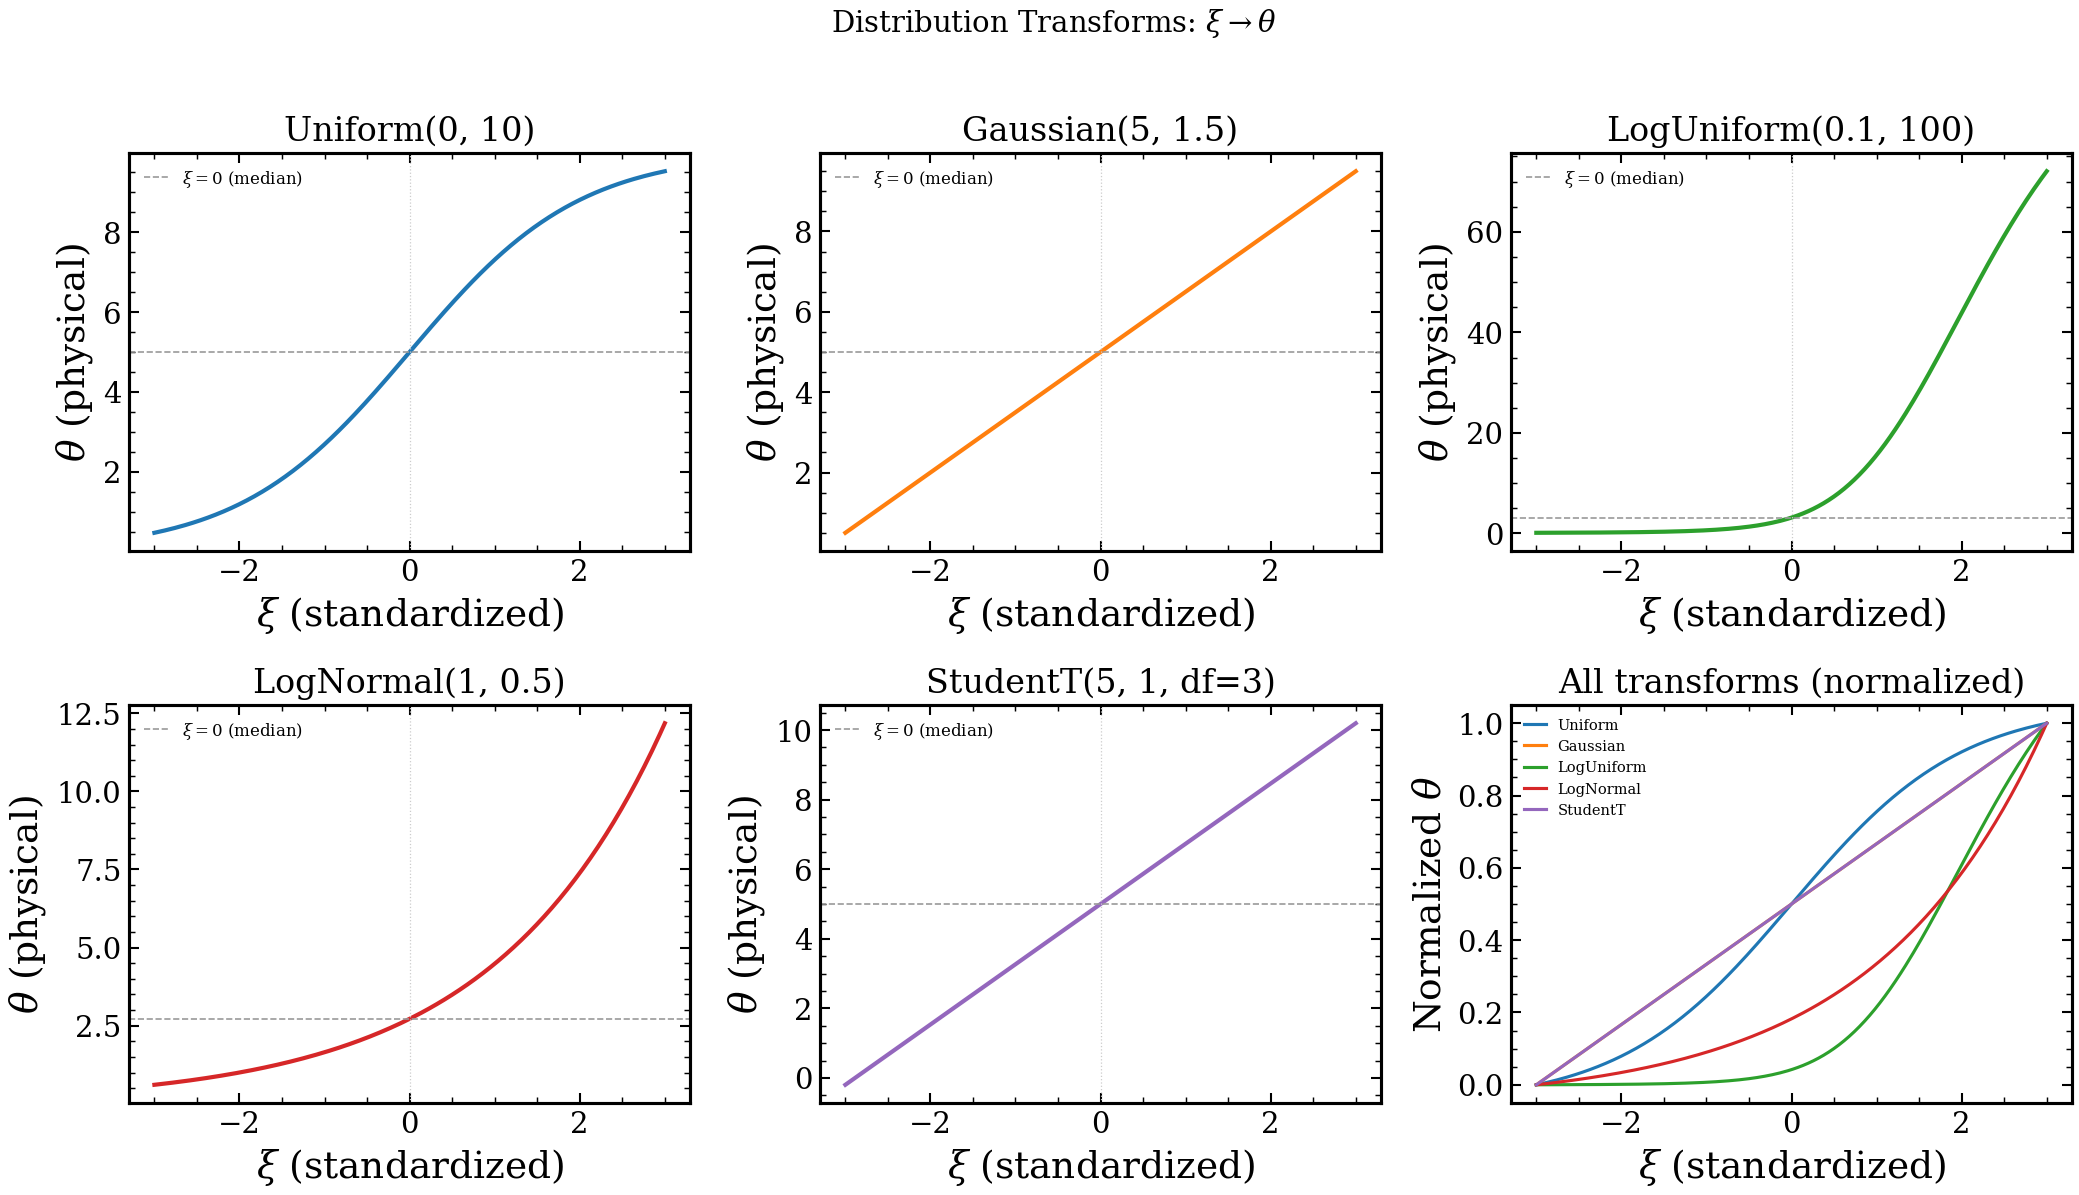

In [3]:
# Visualize unstandardize transforms: xi -> theta for each distribution
xi_grid = jnp.linspace(-3, 3, 200)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

# Skip Fixed for the plot (it is trivially constant)
plot_dists = {k: v for k, v in distributions.items() if not v.is_fixed}
colors = ["C0", "C1", "C2", "C3", "C4"]

for ax, (label, dist), color in zip(axes, plot_dists.items(), colors):
    theta_vals = jnp.array([dist.unstandardize(xi) for xi in xi_grid])
    ax.plot(xi_grid, theta_vals, color=color, lw=2)
    ax.axhline(float(dist.unstandardize(jnp.array(0.0))),
                color="0.6", ls="--", lw=0.8, label="$\\xi=0$ (median)")
    ax.axvline(0, color="0.8", ls=":", lw=0.6)
    ax.set_xlabel("$\\xi$ (standardized)")
    ax.set_ylabel("$\\theta$ (physical)")
    ax.set_title(label)
    ax.legend(fontsize=8)

# Last panel: overlay all transforms (normalized to [0,1] range)
ax = axes[-1]
for (label, dist), color in zip(plot_dists.items(), colors):
    theta_vals = jnp.array([dist.unstandardize(xi) for xi in xi_grid])
    lo, hi = float(theta_vals.min()), float(theta_vals.max())
    if hi > lo:
        normed = (theta_vals - lo) / (hi - lo)
    else:
        normed = jnp.zeros_like(theta_vals)
    ax.plot(xi_grid, normed, color=color, lw=1.5,
            label=label.split("(")[0])
ax.set_xlabel("$\\xi$ (standardized)")
ax.set_ylabel("Normalized $\\theta$")
ax.set_title("All transforms (normalized)")
ax.legend(fontsize=7, loc="upper left")

plt.suptitle("Distribution Transforms: $\\xi \\to \\theta$", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Writing a Custom Prior

To add a new prior, implement the `Distribution` protocol:

1. Subclass `Distribution`
2. Implement `unstandardize(xi)` -- the differentiable forward transform
3. Implement `standardize(theta)` -- the inverse (for initialization)
4. Implement `log_prob(theta)` -- log probability density
5. Implement `sample(key)` -- draw from the prior
6. Define the `bounds` property

That is it.  The `StandardizedForwardModel` handles the rest: your custom
prior plugs directly into `ParamSpec`, and the unified loss
$H = \frac{1}{2}\chi^2 + \frac{1}{2}\xi^T\xi$ works automatically.

Round-trip: theta=0.7 -> xi=1.4024 -> theta=0.7000  (OK)


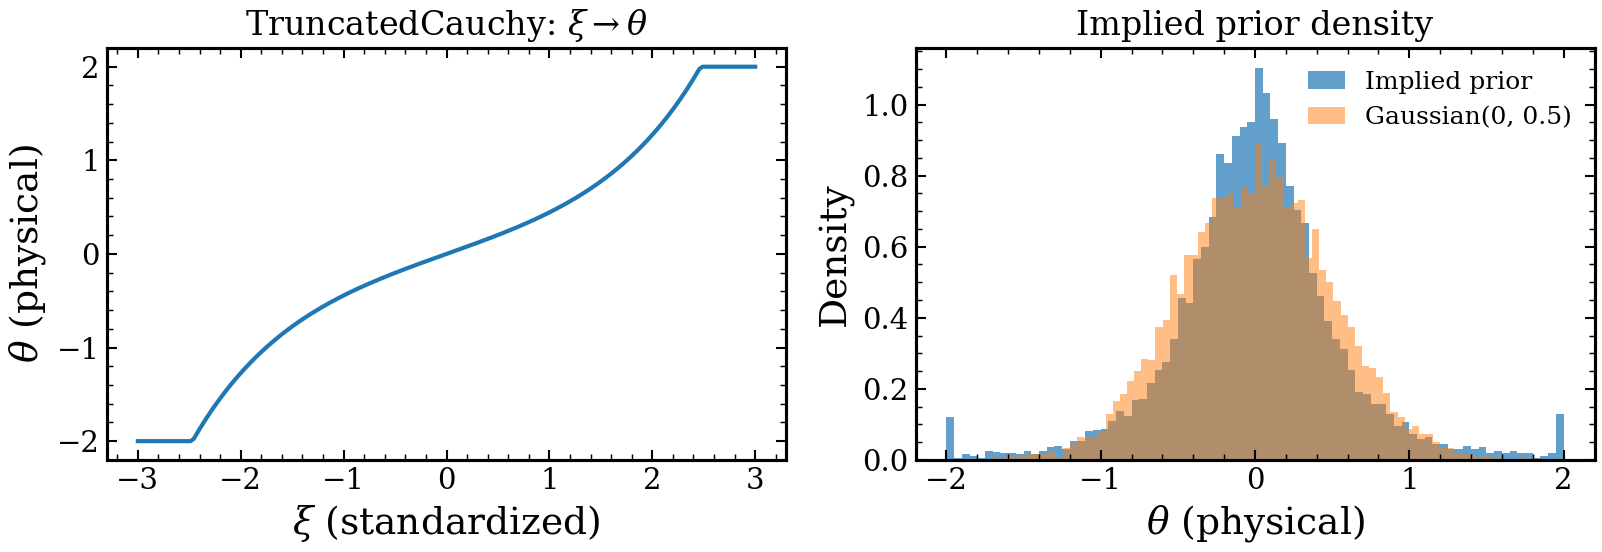

In [4]:
class TruncatedCauchy(Distribution):
    """Cauchy (heavy-tailed) prior truncated to [lo, hi].

    Useful for parameters that might have outlier-like values:
    metallicity, dust optical depth, or burst amplitudes.

    The Cauchy distribution has *no finite moments* -- heavier tails
    than any Student-t with finite df. Truncation keeps values physical.
    """

    def __init__(self, loc: float, scale: float,
                 lo: float = float("-inf"), hi: float = float("inf")):
        if scale <= 0:
            raise ValueError(f"TruncatedCauchy requires scale > 0, got {scale}")
        self._loc = float(loc)
        self._scale = float(scale)
        self._lo = float(lo)
        self._hi = float(hi)

    @property
    def bounds(self):
        return (self._lo, self._hi)

    def sample(self, key):
        # Cauchy = Gaussian / Gaussian (ratio of normals)
        k1, k2 = jax.random.split(key)
        z1 = jax.random.normal(k1)
        z2 = jax.random.normal(k2)
        cauchy = z1 / jnp.maximum(jnp.abs(z2), 1e-10)
        return jnp.clip(self._loc + self._scale * cauchy, self._lo, self._hi)

    def log_prob(self, x):
        z = (x - self._loc) / self._scale
        lp = -jnp.log(jnp.pi * self._scale * (1 + z**2))
        in_bounds = (x >= self._lo) & (x <= self._hi)
        return jnp.where(in_bounds, lp, -jnp.inf)

    def unstandardize(self, xi):
        """xi ~ N(0,1) -> Cauchy via tan transform, clipped to bounds.

        The key identity: if Z ~ N(0,1), then tan(pi * Phi(Z) - pi/2)
        is Cauchy. We use a simpler sigmoid-based approximation that
        is numerically stable and JAX-differentiable.
        """
        # Approximate: map through sigmoid to (0,1), then through
        # Cauchy quantile function (inverse CDF = tan(pi*(p - 0.5)))
        p = jax.nn.sigmoid(xi)  # (0, 1)
        cauchy_draw = jnp.tan(jnp.pi * (p - 0.5))
        theta = self._loc + self._scale * cauchy_draw
        return jnp.clip(theta, self._lo, self._hi)

    def standardize(self, theta):
        """Inverse: theta -> xi."""
        cauchy_draw = (theta - self._loc) / self._scale
        p = jnp.arctan(cauchy_draw) / jnp.pi + 0.5
        p = jnp.clip(p, 1e-6, 1 - 1e-6)
        return jnp.log(p / (1 - p))  # logit

    def __repr__(self):
        return (f"TruncatedCauchy(loc={self._loc}, scale={self._scale}, "
                f"lo={self._lo}, hi={self._hi})")

# --- Verify it works ---
cauchy = TruncatedCauchy(loc=0.0, scale=0.5, lo=-2.0, hi=2.0)
xi_test = jnp.linspace(-3, 3, 200)
theta_cauchy = jnp.array([cauchy.unstandardize(x) for x in xi_test])

# Round-trip test
theta_check = 0.7
xi_rt = cauchy.standardize(jnp.array(theta_check))
theta_rt = cauchy.unstandardize(xi_rt)
print(f"Round-trip: theta={theta_check} -> xi={float(xi_rt):.4f} "
      f"-> theta={float(theta_rt):.4f}  "
      f"({'OK' if abs(float(theta_rt) - theta_check) < 1e-4 else 'FAIL'})")

# Plot the transform and implied density
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(xi_test, theta_cauchy, "C0", lw=2)
axes[0].set_xlabel("$\\xi$ (standardized)")
axes[0].set_ylabel("$\\theta$ (physical)")
axes[0].set_title("TruncatedCauchy: $\\xi \\to \\theta$")

# Implied prior density via sampling
key_samples = jax.random.PRNGKey(42)
xi_samples = jax.random.normal(key_samples, (10000,))
theta_samples = jnp.array([cauchy.unstandardize(x) for x in xi_samples])
axes[1].hist(np.array(theta_samples), bins=80, density=True, alpha=0.7,
             color="C0", label="Implied prior")
# Compare with standard Gaussian
gauss = Gaussian(0.0, 0.5, lo=-2.0, hi=2.0)
theta_gauss = jnp.array([gauss.unstandardize(x) for x in xi_samples])
axes[1].hist(np.array(theta_gauss), bins=80, density=True, alpha=0.5,
             color="C1", label="Gaussian(0, 0.5)")
axes[1].set_xlabel("$\\theta$ (physical)")
axes[1].set_ylabel("Density")
axes[1].set_title("Implied prior density")
axes[1].legend()

plt.tight_layout()
plt.show()

## Custom PSD Models

The default PSD is the **Damped Random Walk** (DRW), which has a fixed
spectral slope of $-2$ at high frequencies:

$$P(f) = \frac{\sigma^2}{1 + (2\pi f \tau)^2}$$

For more flexibility, write a custom PSD function with this signature:

```python
def my_psd(sigma, tau_yr, n_grid, log_ages) -> sqrt_power:
    """Return sqrt(P(f)), shape (n_grid//2 + 1,)."""
    ...
```

Pass it to `StandardizedForwardModel(model, psd_model=my_psd)`.
The model will use your PSD to build the correlated field
$x(t) = \text{IFFT}(\sqrt{P} \cdot \xi)$ instead of the DRW.

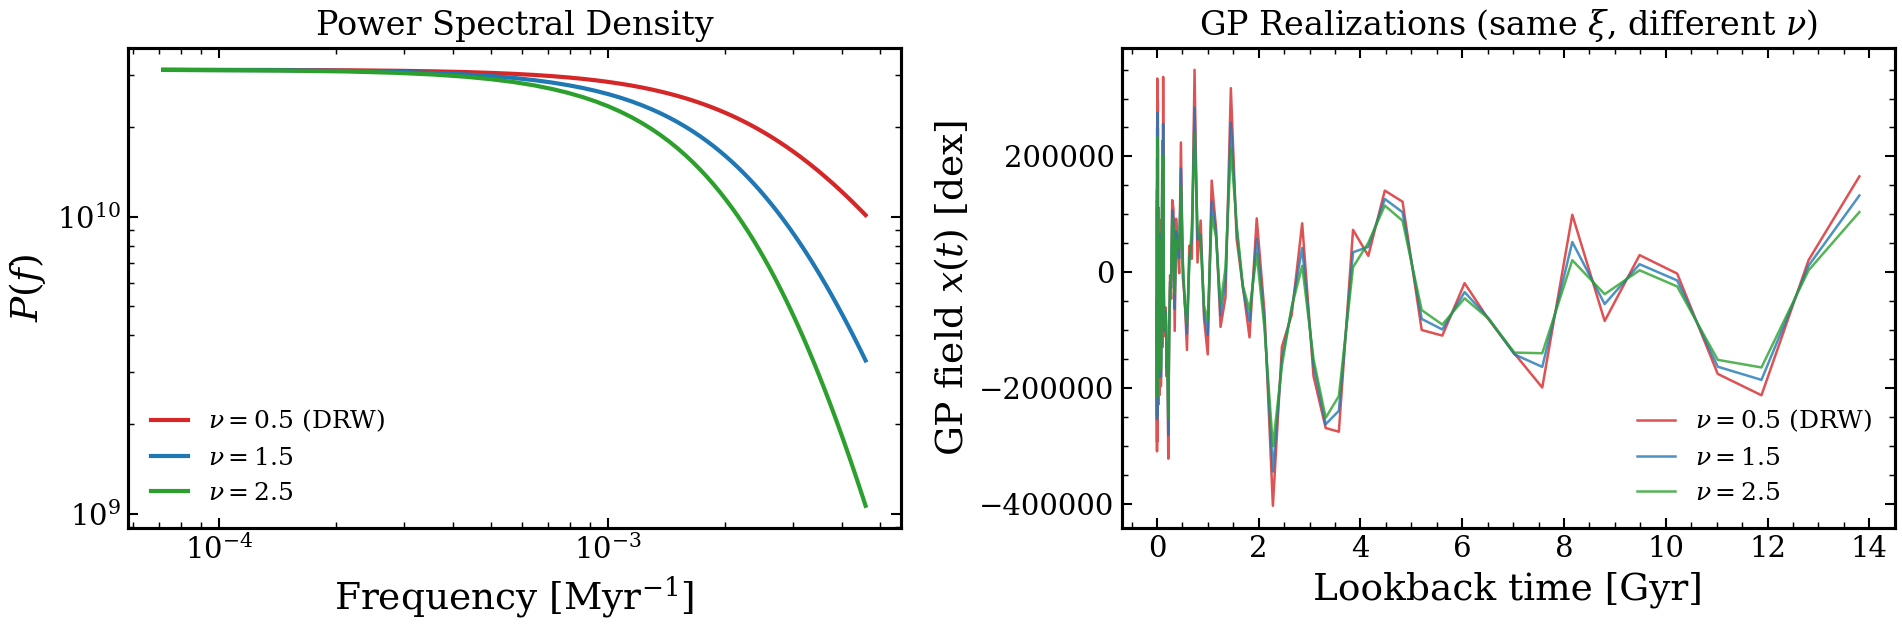

Higher nu = smoother GP realizations (steeper high-freq rolloff)


In [5]:
def matern_psd(sigma, tau_yr, n_grid, log_ages, nu=1.5):
    """Matern PSD with variable smoothness parameter nu.

    Spectral density:
        P(f) ~ sigma^2 * (1 + (2*pi*f*tau)^2)^(-(nu + 0.5))

    Special cases:
        nu = 0.5  -> DRW (exponential covariance)
        nu = 1.5  -> once-differentiable
        nu = 2.5  -> twice-differentiable
        nu -> inf -> squared-exponential (infinitely smooth)

    Parameters
    ----------
    sigma : float
        PSD amplitude (dex of SFR variability).
    tau_yr : float
        Correlation timescale (years).
    n_grid : int
        Number of grid points.
    log_ages : array
        Log10 age grid.
    nu : float
        Matern smoothness parameter.

    Returns
    -------
    array, shape (n_grid//2 + 1,)
        sqrt(P(f)) for the real FFT frequencies.
    """
    # Time spacing from log-age grid
    ages = 10**log_ages
    dt = jnp.mean(jnp.diff(ages))
    freqs = jnp.fft.rfftfreq(n_grid, d=dt)

    # Matern spectral density
    power = sigma**2 * (1 + (2 * jnp.pi * freqs * tau_yr)**2)**(-(nu + 0.5))

    # Normalize so variance matches sigma^2
    power = power * (n_grid * dt)

    return jnp.sqrt(jnp.maximum(power, 1e-30))

# Compare DRW vs Matern for different nu
n_grid = 128
log_ages = make_log_age_grid(n_grid)
sigma, tau_yr = 1.5, 50e6  # 50 Myr

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: PSD shapes
nu_values = [0.5, 1.5, 2.5]
colors_nu = ["C3", "C0", "C2"]
labels_nu = ["$\\nu=0.5$ (DRW)", "$\\nu=1.5$", "$\\nu=2.5$"]

ages = 10**log_ages
dt = float(jnp.mean(jnp.diff(ages)))
freqs = jnp.fft.rfftfreq(n_grid, d=dt)
freqs_myr = freqs * 1e6  # convert to 1/Myr

for nu, color, label in zip(nu_values, colors_nu, labels_nu):
    sqrt_p = matern_psd(sigma, tau_yr, n_grid, log_ages, nu=nu)
    power = sqrt_p**2
    axes[0].loglog(freqs_myr[1:], power[1:], color=color, lw=2, label=label)

axes[0].set_xlabel("Frequency [Myr$^{-1}$]")
axes[0].set_ylabel("$P(f)$")
axes[0].set_title("Power Spectral Density")
axes[0].legend()

# Right: GP realizations
key = jax.random.PRNGKey(42)
t_lookback_gyr = ages / 1e9

for nu, color, label in zip(nu_values, colors_nu, labels_nu):
    sqrt_p = matern_psd(sigma, tau_yr, n_grid, log_ages, nu=nu)
    xi_field = jax.random.normal(key, (n_grid,))
    x_field = jnp.fft.irfft(
        sqrt_p[:n_grid // 2 + 1] * jnp.fft.rfft(xi_field),
        n=n_grid,
    )
    axes[1].plot(t_lookback_gyr, x_field, color=color, lw=1.2,
                 label=label, alpha=0.8)

axes[1].set_xlabel("Lookback time [Gyr]")
axes[1].set_ylabel("GP field $x(t)$ [dex]")
axes[1].set_title("GP Realizations (same $\\xi$, different $\\nu$)")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Higher nu = smoother GP realizations (steeper high-freq rolloff)")

Latent dimensions: 137
Domain: ['dust_tau_bc', 'dust_tau_diff', 'met_logzsol', 'psd_sigma', 'psd_tau_myr']... + psd_xi((128,))


  Step     0/500: loss = 158.3999
  Step   200/500: loss = 1.1952
  Step   400/500: loss = 1.0801
  Step   499/500: loss = 1.0445
  MAP (ADAM) complete in 0.2s, 500 steps
Ray Tracing: 137 params, 50 burn-in + 200 samples, 10 leapfrog/step, step_size=0.0100


  Ray Tracing complete in 0.4s. Acceptance: 95.5% (overall), 95.5% (post burn-in). Samples: 200


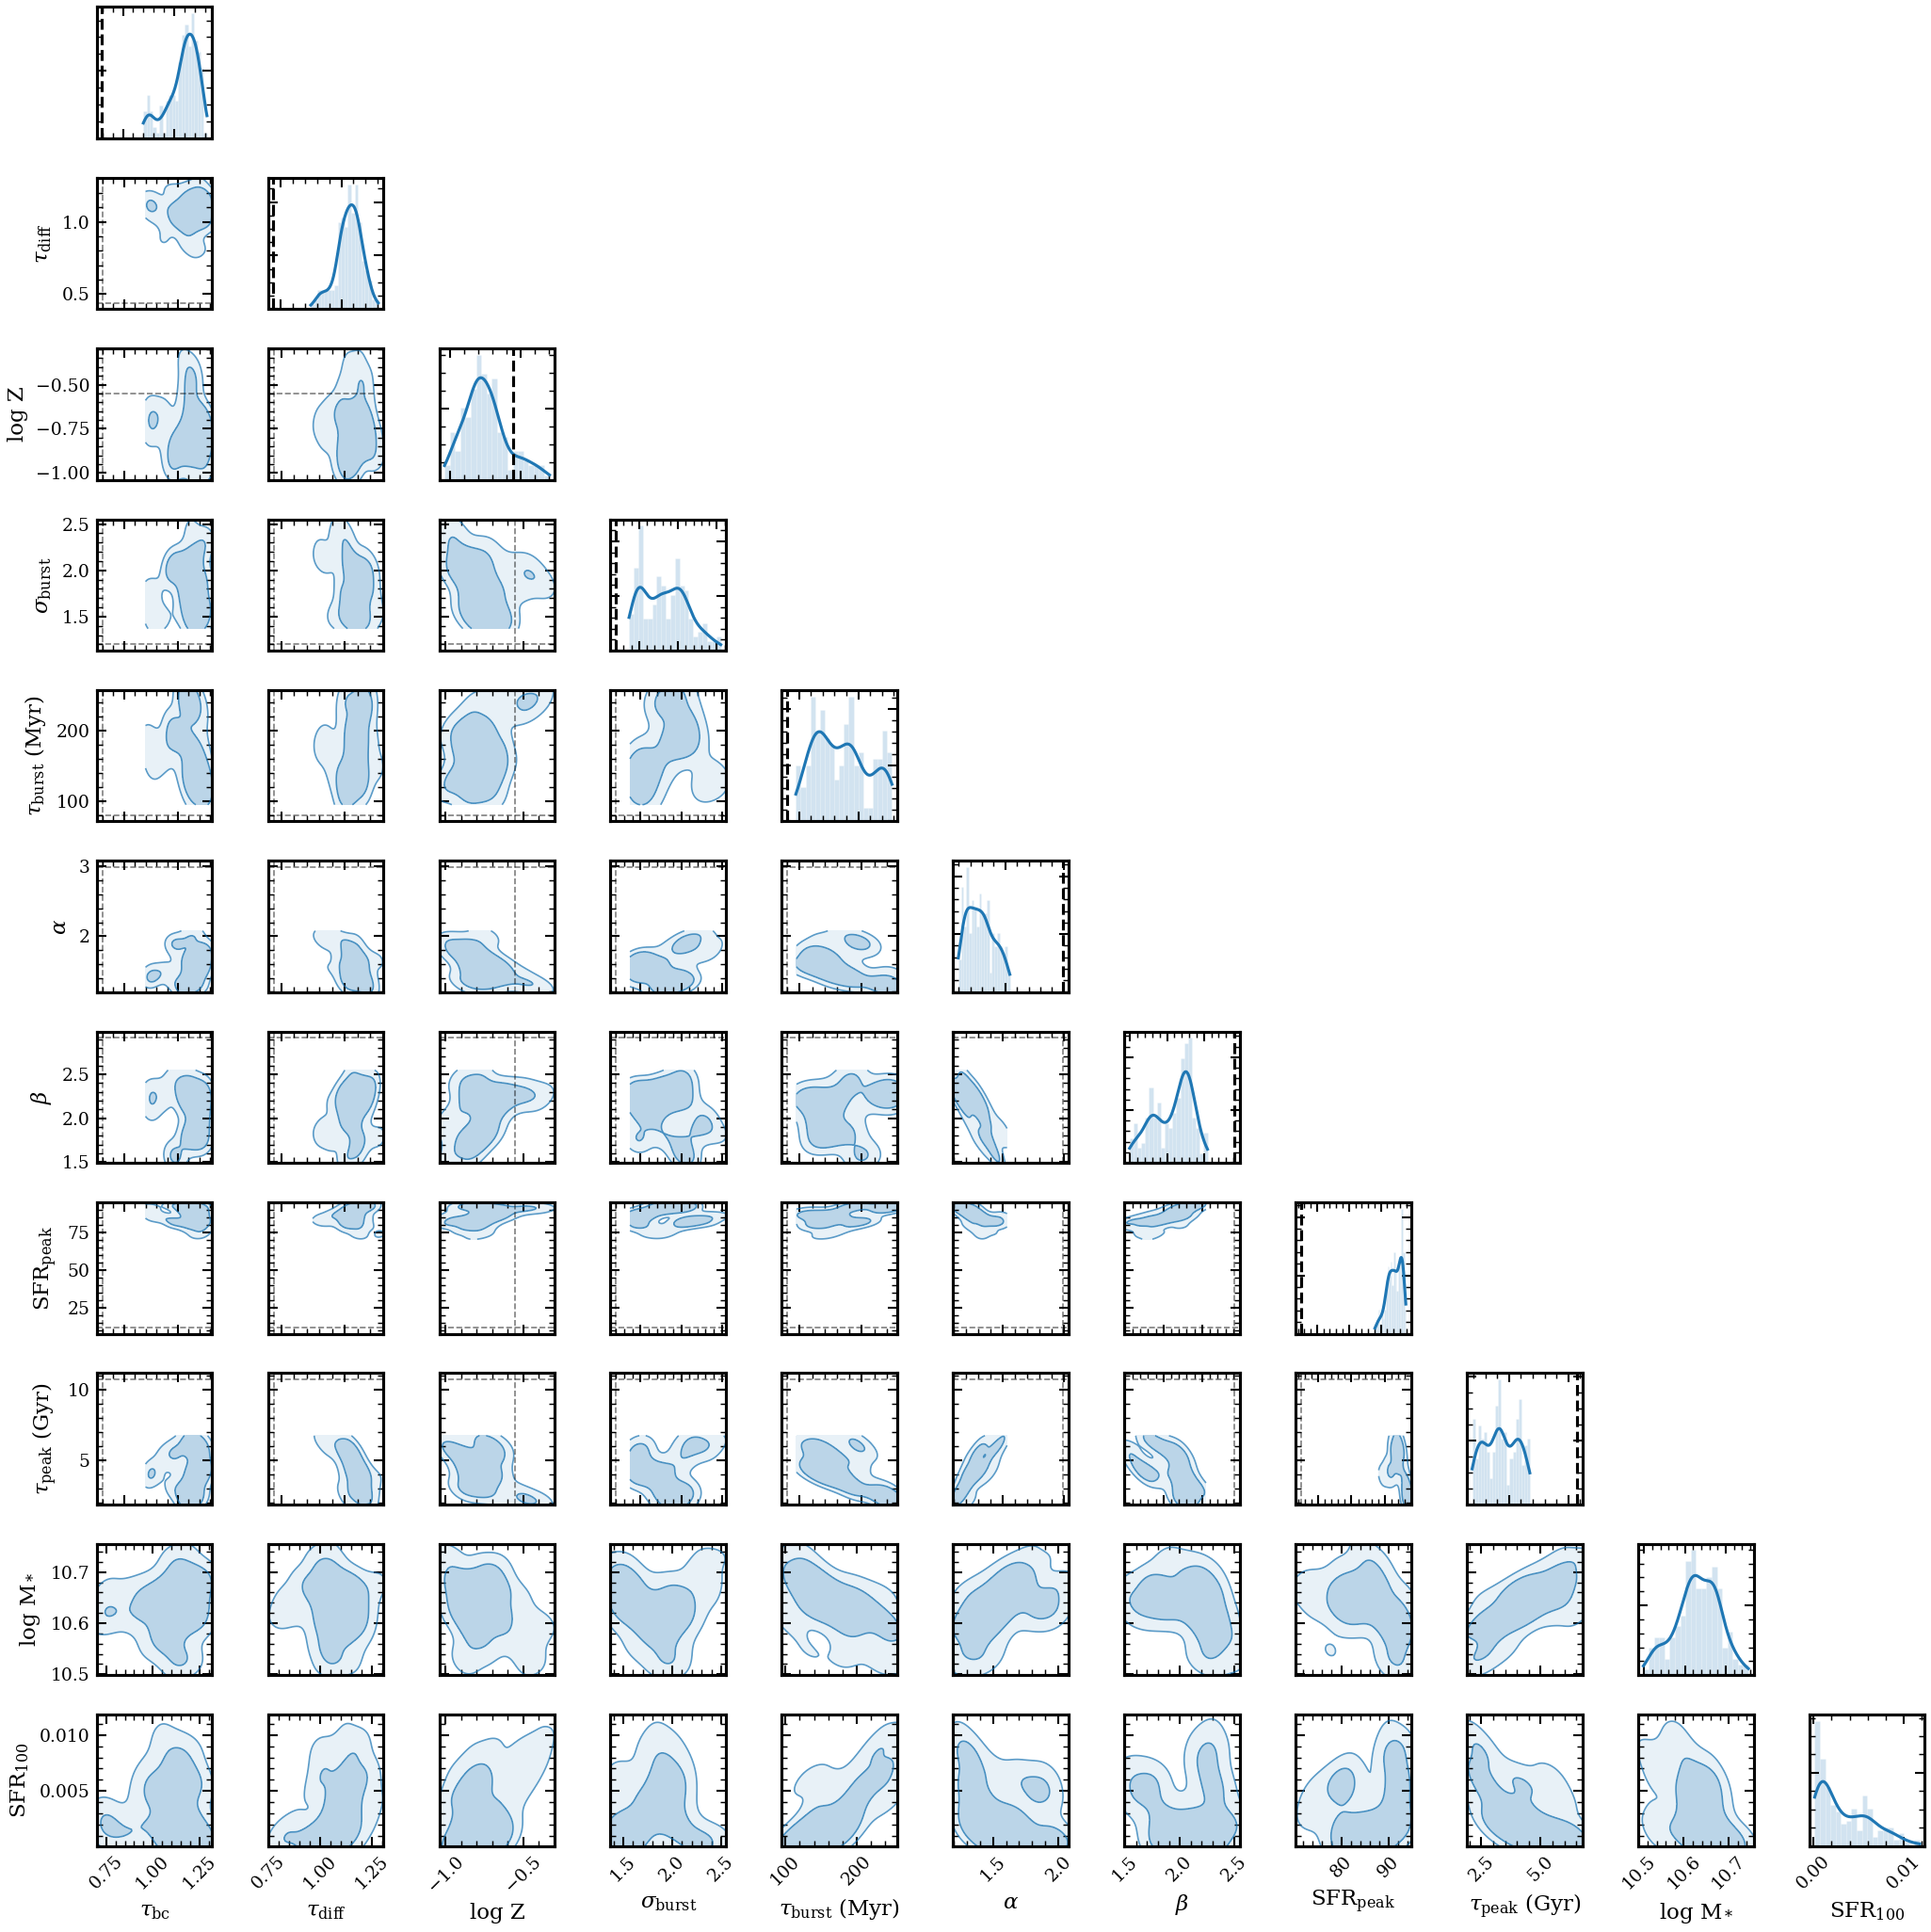

Custom PSD integrates seamlessly -- same loss, same samplers.


In [6]:
# Use the Matern PSD in a StandardizedForwardModel
from functools import partial

spec_stoch = ParamSpec(
    sfh_alpha=Uniform(0.5, 3.0),
    sfh_beta=Uniform(0.5, 3.0),
    sfh_tau_peak_gyr=Uniform(0.5, 13.0),
    sfh_peak_sfr=Uniform(0.1, 100.0),
    psd_sigma=Uniform(0.1, 4.0),
    psd_tau_myr=Uniform(1.0, 300.0),
    met_logzsol=Uniform(-2.0, 0.5),
    dust_tau_bc=Uniform(0.0, 2.0),
    dust_tau_diff=Uniform(0.0, 2.0),
    dust_slope=Fixed(-0.7),
    redshift=Fixed(0.1),
    stochastic=True,
    n_grid=128,
)
model = Model(spec_stoch, ssp_data, filters=filters)

# StandardizedForwardModel with Matern nu=1.5
matern_15 = partial(matern_psd, nu=1.5)
smodel = StandardizedForwardModel(model, psd_model=matern_15)

print(f"Latent dimensions: {smodel.n_latent}")
print(f"Domain: {list(smodel.domain.keys())[:5]}... + psd_xi({smodel.domain['psd_xi']})")

# Generate a mock and fit
key = jax.random.PRNGKey(99)
true_params = spec_stoch.sample(key)
true_params = {**true_params, "psd_sigma": 1.2, "psd_tau_myr": 80.0}

mock = model.mock(true_params, snr=20.0, key=key)
fitter = Fitter(model, mock.flux_obs, mock.noise,
                data_type="photometry")

result_map = fitter.run("map", n_steps=500)
result_rt = fitter.run("raytrace", init_from=result_map,
                       n_burnin=50, n_steps=200, step_size=0.01)

# Corner plot of physical params
fig_corner = safe_corner(result_rt, truths=true_params, color="C0",
                         label="Matern $\\nu$=1.5")
plt.show()

print("Custom PSD integrates seamlessly -- same loss, same samplers.")

## Custom Dust Models

The default is Charlot \& Fall (2000): a two-component model with
birth-cloud and diffuse ISM attenuation.  The function signature is:

```python
def charlot_fall(wavelength, age_grid, tau_v1, tau_v2,
                 n_slope=-0.7, t_birth=1e7) -> attenuation_factor:
    """Returns exp(-tau_lambda), shape (n_ages, n_wave)."""
```

To use a different attenuation law, write a JAX function with the same
signature and pass it to the model.

Common alternatives:
- **Calzetti (2000):** single power law with UV bump
- **Kriek \& Conroy (2013):** modified Calzetti with variable UV bump
- **Salim \& Narayanan (2020):** flexible attenuation curves

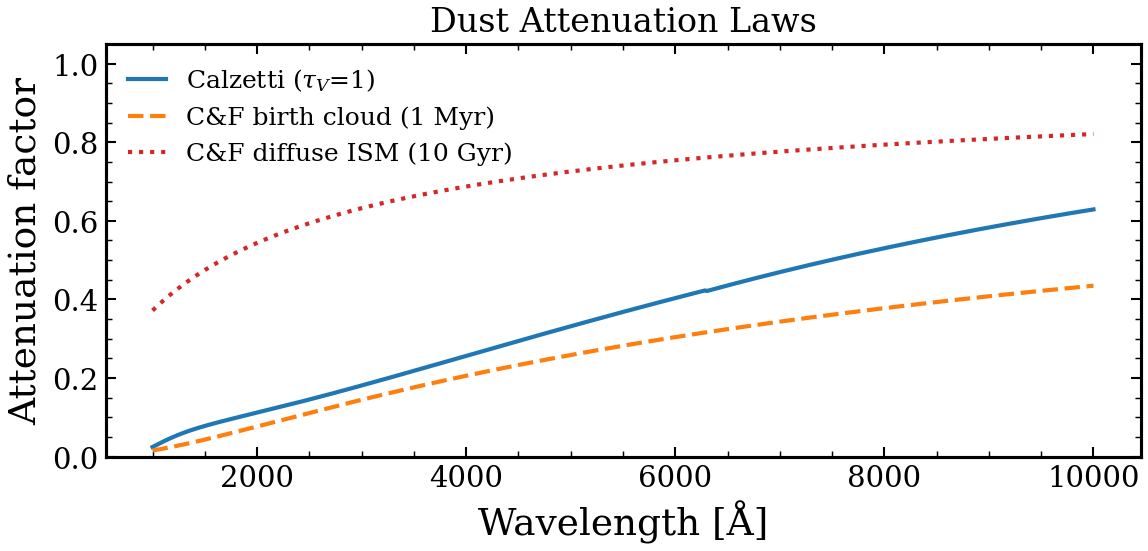

In [7]:
def calzetti_attenuation(wavelength, tau_v, delta=0.0, B=0.0):
    """Calzetti (2000) attenuation curve with optional UV bump.

    This is a sketch showing the interface -- the actual implementation
    would include the full polynomial fit from Calzetti et al.

    Parameters
    ----------
    wavelength : array, shape (n_wave,)
        Rest-frame wavelength in Angstrom.
    tau_v : float
        V-band optical depth.
    delta : float
        Power-law deviation from Calzetti slope (Noll+2009).
    B : float
        UV bump strength at 2175 Angstrom.

    Returns
    -------
    array, shape (n_wave,)
        Attenuation factor exp(-tau_lambda).
    """
    # Simplified Calzetti curve (real version uses piecewise polynomial)
    wave_um = wavelength / 1e4  # Angstrom -> micron
    k_lambda = 2.659 * (-1.857 + 1.040 / wave_um)  # valid for 0.63-2.2 um
    k_lambda = jnp.where(
        wavelength < 6300,
        2.659 * (-2.156 + 1.509 / wave_um - 0.198 / wave_um**2
                 + 0.011 / wave_um**3),
        k_lambda,
    )

    # Optional UV bump (Drude profile at 2175 A)
    bump = B * (wavelength * 350.0)**2 / (
        (wavelength**2 - 2175.0**2)**2 + (wavelength * 350.0)**2
    )

    # Power-law modification (Noll+2009)
    k_mod = (k_lambda + 4.05) * (wavelength / 5500.0)**delta + bump

    tau_lambda = tau_v * k_mod / 4.05
    return jnp.exp(-jnp.maximum(tau_lambda, 0.0))

# Compare Calzetti vs Charlot & Fall
wave = jnp.linspace(1000, 10000, 500)
age_grid = jnp.array([1e6, 1e7, 1e8, 1e9, 1e10])

fig, ax = plt.subplots(figsize=(8, 4))

# Calzetti (single component)
atten_calzetti = calzetti_attenuation(wave, tau_v=1.0)
ax.plot(wave, atten_calzetti, "C0", lw=2, label="Calzetti ($\\tau_V$=1)")

# Charlot & Fall (young and old stars)
atten_cf = charlot_fall(wave, age_grid, tau_v1=1.0, tau_v2=0.3)
ax.plot(wave, atten_cf[0], "C1", lw=2, ls="--",
        label="C&F birth cloud (1 Myr)")
ax.plot(wave, atten_cf[-1], "C3", lw=2, ls=":",
        label="C&F diffuse ISM (10 Gyr)")

ax.set_xlabel("Wavelength [\u00c5]")
ax.set_ylabel("Attenuation factor")
ax.set_title("Dust Attenuation Laws")
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

## Custom Mean SFH Models

The default mean SFH is the **double power law** (Carnall+2018,
Behroozi+2013):

$$\text{SFR}(t) = \frac{A}{(t/\tau)^\alpha + (t/\tau)^{-\beta}}$$

The GP stochastic field modulates this: $\text{SFR}_{\rm full}(t) =
\text{SFR}_{\rm mean}(t) \cdot \exp(x(t))$.

To use a different parametric form, write a JAX function:

```python
def my_mean_sfh(t_lookback, **params) -> SFR:
    """SFR in Msun/yr at each lookback time (years)."""
```

Built-in alternatives: `delayed_tau`, `constant_sfh`, `powerlaw_sfh`.

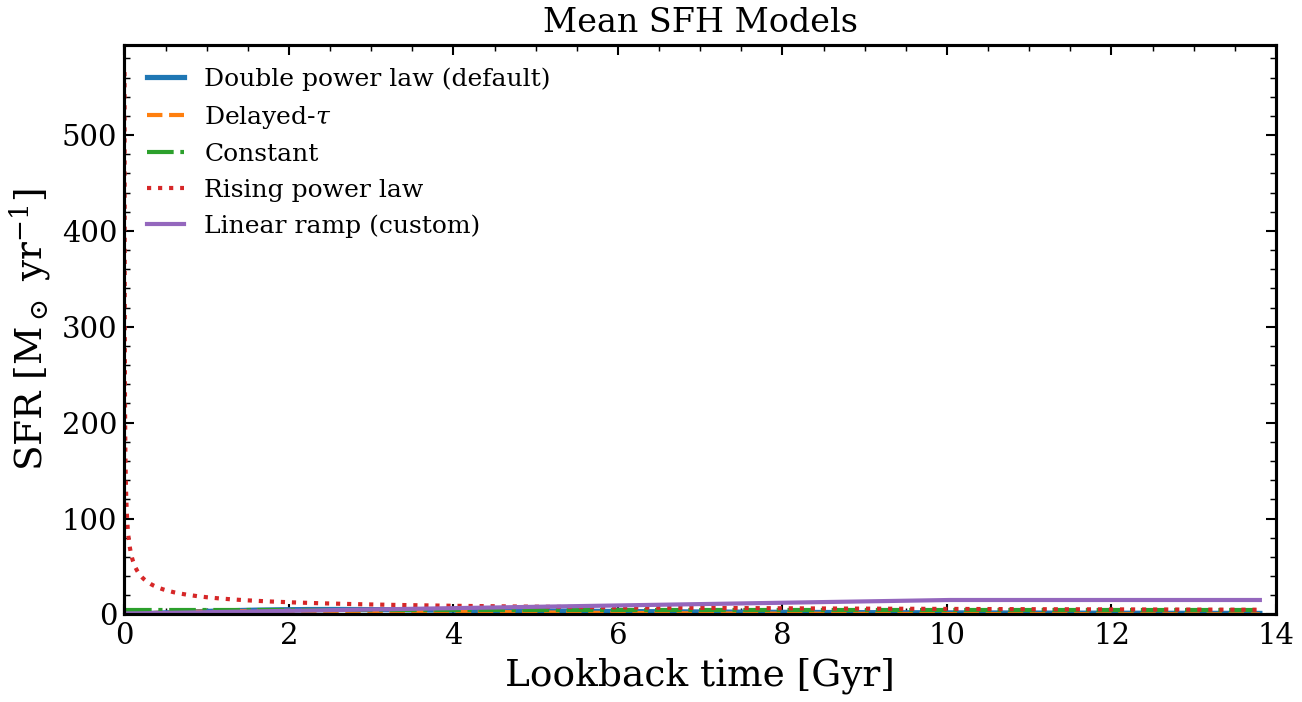

Any of these can serve as the smooth baseline for the GP field.


In [8]:
# Compare mean SFH models
t_lookback = jnp.logspace(6, 10.14, 300)  # 1 Myr to 13.8 Gyr
t_gyr = t_lookback / 1e9

fig, ax = plt.subplots(figsize=(9, 5))

# Double power law (default)
sfr_dpl = double_powerlaw(t_lookback, alpha=1.5, beta=1.0,
                           tau=3e9, norm=10.0)
ax.plot(t_gyr, sfr_dpl, "C0", lw=2.5, label="Double power law (default)")

# Delayed-tau
sfr_dtau = delayed_tau(t_lookback, tau=2e9, norm=5e-9)
ax.plot(t_gyr, sfr_dtau, "C1", lw=2, ls="--", label="Delayed-$\\tau$")

# Constant
sfr_const = constant_sfh(t_lookback, norm=5.0)
ax.plot(t_gyr, sfr_const, "C2", lw=2, ls="-.", label="Constant")

# Rising power law
sfr_rising = powerlaw_sfh(t_lookback, alpha=-0.5, norm=8.0, t_ref=5e9)
ax.plot(t_gyr, sfr_rising, "C3", lw=2, ls=":", label="Rising power law")

# Custom: linear ramp
def linear_ramp(t_lookback, sfr_start, sfr_end, t_start=1e8, t_end=1e10):
    """Linearly interpolated SFH."""
    frac = jnp.clip((t_lookback - t_start) / (t_end - t_start), 0, 1)
    return sfr_start + (sfr_end - sfr_start) * frac

sfr_ramp = linear_ramp(t_lookback, sfr_start=1.0, sfr_end=15.0)
ax.plot(t_gyr, sfr_ramp, "C4", lw=2, label="Linear ramp (custom)")

ax.set_xlabel("Lookback time [Gyr]")
ax.set_ylabel("SFR [M$_\\odot$ yr$^{-1}$]")
ax.set_title("Mean SFH Models")
ax.legend(loc="upper left")
ax.set_xlim(0, 14)
ax.set_ylim(0, None)
plt.tight_layout()
plt.show()

print("Any of these can serve as the smooth baseline for the GP field.")

## Using Different SSP Templates

diffsed ships with **FSPS/MIST** templates accessed via
[DSPS](https://github.com/ArgonneCPAC/dsps) (Hearin+2023).  The SSP
data contains:

- `ssp_lgmet`: log10(Z) metallicity grid (absolute, not solar-scaled)
- `ssp_lg_age_gyr`: log10(age/Gyr) age grid
- `ssp_wave`: wavelength array (Angstrom)
- `ssp_flux`: specific luminosity array, shape (n_met, n_age, n_wave)

To use different SSP templates (MILES, BaSeL, PARSEC, BC03), format them
into the same structure.  The key requirement: the flux array must be on a
regular grid in (metallicity, age) so that JAX interpolation works.

**Important:** The metallicity grid uses $\log_{10}(Z)$ absolute, **not**
$\log_{10}(Z/Z_\odot)$.  The solar offset is
`LOG10_ZSUN = -1.848`.

## Custom Filter Sets

`load_filter_set(["sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z"])` loads the default 5-band SDSS ugriz filters.
You can load any filter from the
[SVO Filter Profile Service](http://svo2.cab.inta-csic.es/theory/fps/):

- **JWST NIRCam:** F090W, F115W, F150W, F200W, F277W, F356W, F444W
- **Euclid NISP:** Y, J, H
- **Roman WFI:** F062, F087, F106, F129, F158, F184, F213, F146
- **HST ACS/WFC3:** F435W, F606W, F814W, F105W, F125W, F160W

Each filter is a dict with `wave` (Angstrom) and `transmission` arrays.

Filter set: 5 bands
Band                  Wave range   Effective wave
--------------------------------------------------
  sdss_u          3055 --   4005 A          3562 A


  sdss_g          3805 --   5530 A          4719 A
  sdss_r          5430 --   6980 A          6185 A


  sdss_i          6705 --   8380 A          7500 A
  sdss_z          7980 --  10830 A          8961 A


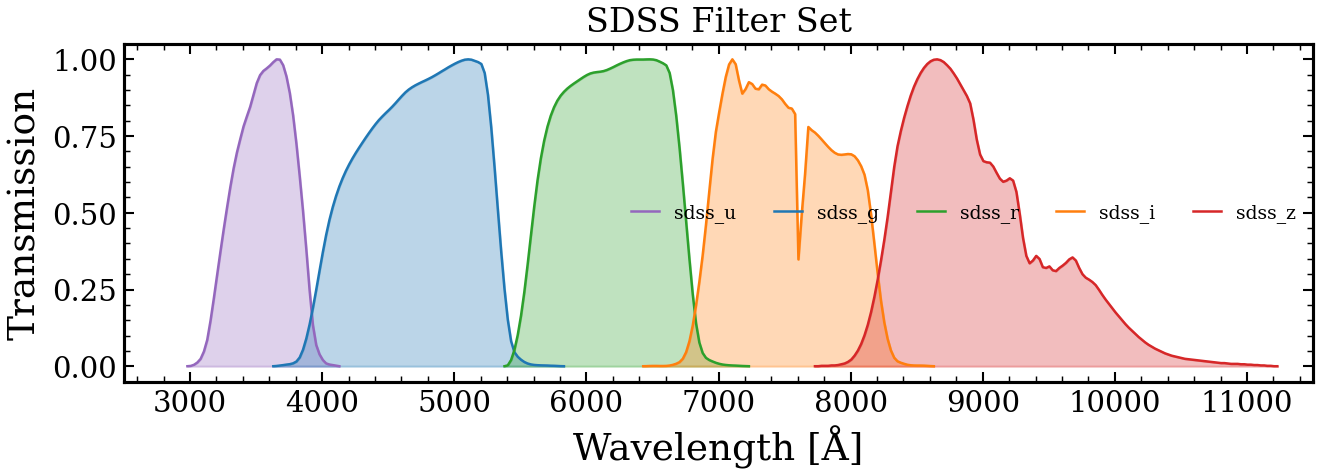


To add custom filters, create a dict with 'wave' and 'transmission' arrays.
The filter effective wavelength is used for photometric predictions.


In [9]:
# Inspect the SDSS filter set
# filter_curves is a list of FilterCurve NamedTuples with .wave, .trans, .name
print(f"Filter set: {len(filter_curves)} bands")
print(f"{'Band':10s}  {'Wave range':>20s}  {'Effective wave':>15s}")
print("-" * 50)
for filt in filter_curves:
    wave_lo = float(filt.wave[filt.trans > 0.01 * filt.trans.max()].min())
    wave_hi = float(filt.wave[filt.trans > 0.01 * filt.trans.max()].max())
    print(f"  {filt.name:10s}  {wave_lo:8.0f} -- {wave_hi:6.0f} A  "
          f"{float(jnp.sum(filt.wave * filt.trans) / jnp.sum(filt.trans)):12.0f} A")

# Plot filter curves
fig, ax = plt.subplots(figsize=(9, 3.5))
colors_band = ["C4", "C0", "C2", "C1", "C3"]
for filt, color in zip(filter_curves, colors_band):
    ax.fill_between(filt.wave, filt.trans, alpha=0.3, color=color)
    ax.plot(filt.wave, filt.trans, color=color, lw=1.2, label=filt.name)

ax.set_xlabel("Wavelength [\u00c5]")
ax.set_ylabel("Transmission")
ax.set_title("SDSS Filter Set")
ax.legend(ncol=5, fontsize=9)
ax.set_xlim(2500, 11500)
plt.tight_layout()
plt.show()

print("\nTo add custom filters, create a dict with 'wave' and 'transmission' arrays.")
print("The filter effective wavelength is used for photometric predictions.")

## Making PSD Parameters Free

When `psd_sigma` and `psd_tau_myr` are given `Uniform` priors (not
`Fixed`), the model **infers the PSD from the data**.

The `StandardizedForwardModel` handles this naturally: the PSD parameters
are standardized like any other parameter, and the correlated field
$\sqrt{P(\sigma, \tau)} \cdot \xi$ couples them to the GP.  Gradients
flow through the PSD computation via JAX autodiff.

This is the key to hierarchical inference (Tutorial 05): share
$\sigma_{\rm PSD}$ and $\tau_{\rm PSD}$ across galaxies, and the
ensemble constrains the PSD even when individual galaxies cannot.

True PSD: sigma=1.8, tau=60 Myr
Free parameters: 9 (physical: -119, GP latent: 128)
  Step     0/500: loss = 183.0058
  Step   200/500: loss = 2.8704
  Step   400/500: loss = 2.4857


  Step   499/500: loss = 2.3422
  MAP (ADAM) complete in 0.2s, 500 steps
Ray Tracing: 137 params, 100 burn-in + 300 samples, 10 leapfrog/step, step_size=0.0100


  Ray Tracing complete in 0.4s. Acceptance: 99.3% (overall), 99.5% (post burn-in). Samples: 300


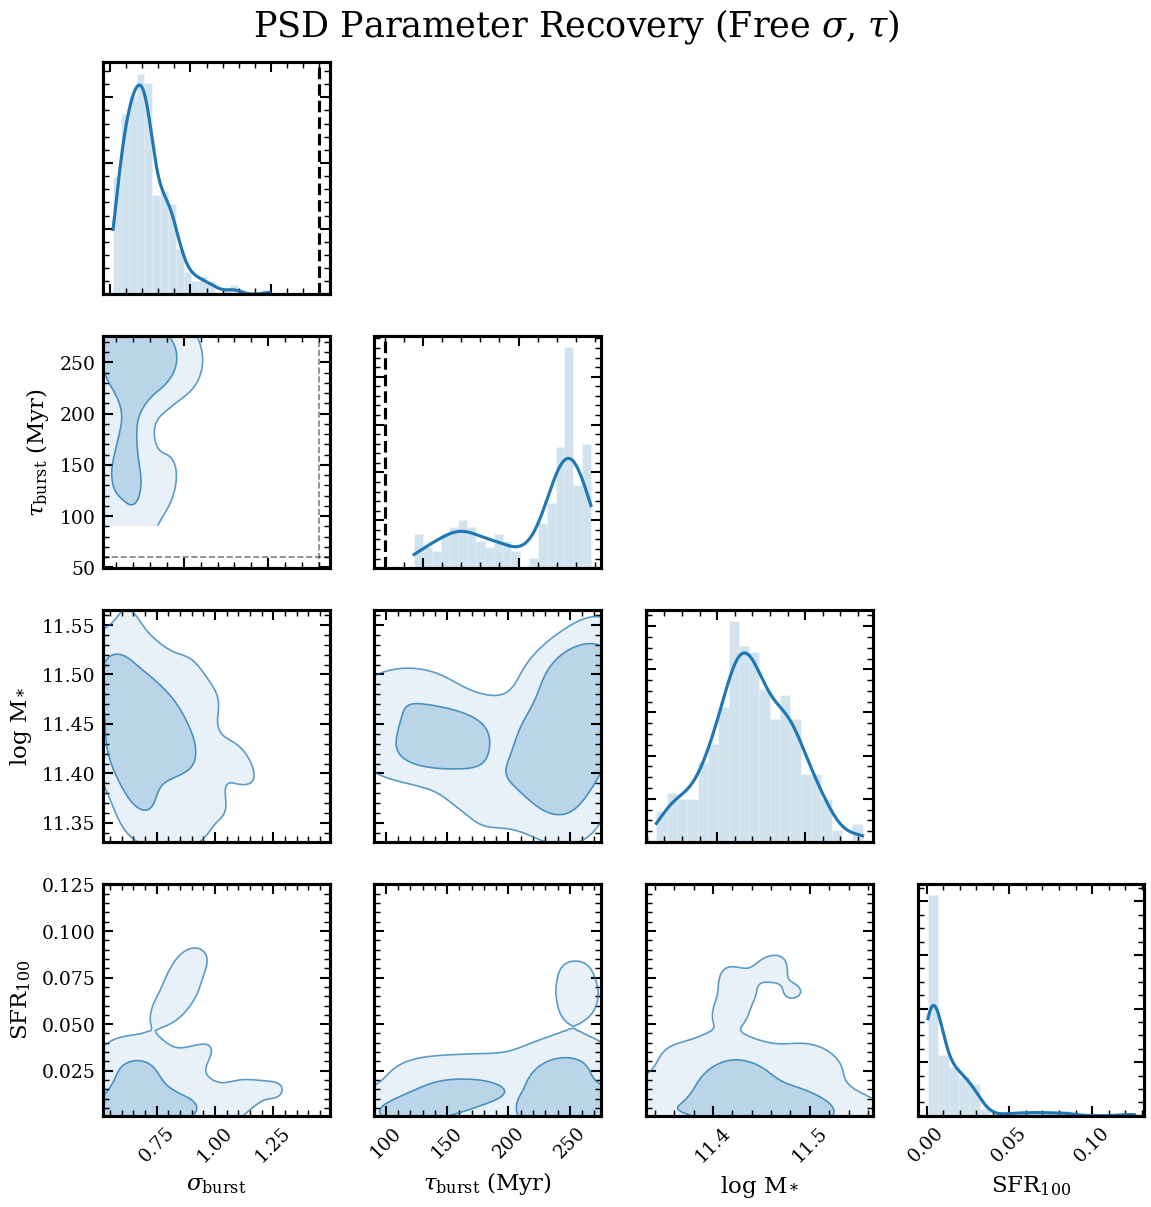

  psd_sigma      : truth=1.80  recovered=0.71 [0.60, 0.87]  MISS
  psd_tau_myr    : truth=60.00  recovered=242.53 [138.23, 259.61]  MISS


In [10]:
# Model with FREE PSD parameters
spec_free_psd = ParamSpec(
    sfh_alpha=Uniform(0.5, 3.0),
    sfh_beta=Uniform(0.5, 3.0),
    sfh_tau_peak_gyr=Uniform(0.5, 13.0),
    sfh_peak_sfr=Uniform(0.1, 100.0),
    psd_sigma=Uniform(0.1, 4.0),       # FREE -- inferred from data
    psd_tau_myr=Uniform(1.0, 300.0),    # FREE -- inferred from data
    met_logzsol=Uniform(-2.0, 0.5),
    dust_tau_bc=Uniform(0.0, 2.0),
    dust_tau_diff=Uniform(0.0, 2.0),
    dust_slope=Fixed(-0.7),
    redshift=Fixed(0.1),
    stochastic=True,
    n_grid=128,
)

model_free = Model(spec_free_psd, ssp_data, filters=filters)

# Generate mock with known PSD
key = jax.random.PRNGKey(2024)
true_free = spec_free_psd.sample(key)
true_free = {**true_free, "psd_sigma": 1.8, "psd_tau_myr": 60.0}

mock_free = model_free.mock(true_free, snr=20.0, key=key)

print(f"True PSD: sigma={true_free['psd_sigma']:.1f}, "
      f"tau={true_free['psd_tau_myr']:.0f} Myr")
print(f"Free parameters: {spec_free_psd.n_free} "
      f"(physical: {spec_free_psd.n_free - 128}, GP latent: 128)")

# Fit with Ray Tracing
fitter_free = Fitter(model_free, mock_free.flux_obs, mock_free.noise,
                     data_type="photometry")
map_free = fitter_free.run("map", n_steps=500)
rt_free = fitter_free.run("raytrace", init_from=map_free,
                          n_burnin=100, n_steps=300, step_size=0.01)

# PSD parameter recovery
fig_psd = safe_corner(rt_free, params=["psd_sigma", "psd_tau_myr"],
                      truths=true_free, color="C0",
                      label="Ray Tracing")
plt.suptitle("PSD Parameter Recovery (Free $\\sigma$, $\\tau$)", y=1.02)
plt.show()

# Quantify
for name in ["psd_sigma", "psd_tau_myr"]:
    lo, med, hi = np.percentile(rt_free.samples[name], [16, 50, 84])
    truth = float(true_free[name])
    covered = "OK" if lo <= truth <= hi else "MISS"
    print(f"  {name:15s}: truth={truth:.2f}  "
          f"recovered={med:.2f} [{lo:.2f}, {hi:.2f}]  {covered}")

## Why This Architecture Works

The $\xi$-standardization is the central design principle.  Here is
why it matters:

**1. One loss function for everything.**

$$H(\xi) = \tfrac{1}{2} \sum_k \left(\frac{d_k - m_k(\xi)}{\sigma_k}\right)^2 + \tfrac{1}{2} \xi^T \xi$$

No prior-specific penalty terms.  No special cases for different
distributions.  The prior is absorbed into `unstandardize`.

**2. Any prior maps through `unstandardize`.**

Uniform, Gaussian, LogNormal, Student-t, Cauchy, or your custom
distribution -- all produce $\xi \sim \mathcal{N}(0, 1)$.  The
`StandardizedForwardModel` does not need to know which prior you chose.

**3. Any sampler works in $\xi$-space.**

MAP (gradient descent), Ray Tracing (stochastic-gradient MCMC), NUTS
(Hamiltonian Monte Carlo), geoVI (geometric variational inference),
MGVI (metric Gaussian VI) -- they all see the same $\xi$-space with
unit Gaussian prior.

**4. JAX autodiff gives gradients through the full pipeline.**

From $\xi$ through the PSD, GP field, SFH, dust, SPS, filter
convolution, to the likelihood -- every step is differentiable.
`jax.grad(loss)` gives exact gradients for free.

This is the key insight from **Information Field Theory**
(En{\ss}lin 2019): standardized coordinates reduce any Bayesian
inference problem to optimizing a single functional $H(\xi)$.
The physics is in the forward model; the statistics is universal.

## Summary

diffsed is designed for extensibility.  The standardized architecture
ensures everything composes cleanly:

| Extension point | What to implement | Example |
|----------------|-------------------|---------|
| **Custom prior** | `Distribution` subclass with `unstandardize`/`standardize` | `TruncatedCauchy` (this notebook) |
| **Custom PSD** | `my_psd(sigma, tau_yr, n_grid, log_ages) -> sqrt_power` | Matern PSD with variable $\nu$ |
| **Custom dust** | JAX function `(wavelength, age_grid, ...) -> attenuation` | Calzetti, Kriek & Conroy |
| **Custom mean SFH** | JAX function `(t_lookback, ...) -> SFR` | Delayed-$\tau$, Diffstar |
| **Custom SSP** | Format as `(lgmet, lg_age_gyr, wave, flux)` arrays | MILES, BaSeL, PARSEC |
| **Custom filters** | Dict with `wave` and `transmission` arrays | JWST, Euclid, Roman |
| **Free PSD params** | Give `Uniform` priors to `psd_sigma`, `psd_tau_myr` | Hierarchical inference |

The key principle: **one loss function, any prior, any sampler.**

For the full design philosophy, see `ARCHITECTURE.md`.
For hierarchical PSD inference, see Tutorial 05.